# NB01 — Data Acquisition & Engineering Pipeline

**Project**: PPE Compliance Detection (Hard Hats & High-Vis Vests)  
**Author**: Nduka  
**Date**: March 2026  

---

## Objective

Merge **three public datasets** (different formats, class names) into one clean YOLO-format dataset.

| # | Dataset | ~Images | Source Format | Key Classes |
|---|---------|---------|---------------|-------------|
| 1 | Construction Site Safety (Kaggle) | 2,801 | YOLO txt | 10 classes (keep 5) |
| 2 | SHWD (GitHub) | 7,581 | VOC XML (`<n>` tag) | hat, person |
| 3 | Pictor-PPE (Google Drive) | 784 | TXT/XML | worker, hat, vest |

### Unified 5-Class Schema

| ID | Name | ID | Name |
|----|------|----|------|
| 0 | `hardhat` | 3 | `no-vest` |
| 1 | `no-hardhat` | 4 | `person` |
| 2 | `vest` | | |

---

## 1. Environment Setup

In [ ]:
# 1.1 Install dependencies (run once, restart kernel)
# !pip install kagglehub opencv-python imagehash pillow lxml tqdm scikit-learn matplotlib pyyaml gdown pandas

In [1]:
# 1.2 Imports
import os, sys, shutil, hashlib, random, csv, json
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
import imagehash
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import yaml
import gdown

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f"Python {sys.version}")
print("All imports successful.")

Python 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
All imports successful.


In [11]:
# 1.3 Directory Structure
PROJECT_ROOT = Path("../")
RAW_DIR        = PROJECT_ROOT / "data" / "raw"
RAW_CSS_DIR    = RAW_DIR / "construction_site_safety"
RAW_SHWD_DIR   = RAW_DIR / "shwd"
RAW_PICTOR_DIR = RAW_DIR / "pictor_ppe"
PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"
MERGED_IMG_DIR = PROCESSED_DIR / "images"
MERGED_LBL_DIR = PROCESSED_DIR / "labels"

for split in ["train", "val", "test"]:
    (MERGED_IMG_DIR / split).mkdir(parents=True, exist_ok=True)
    (MERGED_LBL_DIR / split).mkdir(parents=True, exist_ok=True)
for d in [RAW_CSS_DIR, RAW_SHWD_DIR, RAW_PICTOR_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Raw:       {RAW_DIR.resolve()}")
print(f"Processed: {PROCESSED_DIR.resolve()}")

Raw:       C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\raw
Processed: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed


In [12]:
# 1.4 Class Mapping Constants
UNIFIED_CLASSES = {0: "hardhat", 1: "no-hardhat", 2: "vest", 3: "no-vest", 4: "person"}
NUM_CLASSES = len(UNIFIED_CLASSES)

# CSS: 10 classes -> keep 5
CSS_CLASS_MAP = {0: 0, 2: 1, 7: 2, 4: 3, 5: 4}
CSS_DROP_CLASSES = {1, 3, 6, 8, 9}

# SHWD: XML uses <n> tag (not standard <name>)
SHWD_CLASS_MAP = {"hat": 0, "person": 1}

# Pictor-PPE
PICTOR_CLASS_MAP = {"worker": 4, "hat": 0, "vest": 2}

for cid, cn in UNIFIED_CLASSES.items(): print(f"  {cid}: {cn}")

  0: hardhat
  1: no-hardhat
  2: vest
  3: no-vest
  4: person


In [13]:
# 1.5 Utility Functions

def show_tree(root, max_depth=3, prefix=""):
    dirs  = sorted([e for e in root.iterdir() if e.is_dir() and not e.name.startswith(".")])
    files = [e for e in root.iterdir() if e.is_file()]
    if files:
        ext_counts = Counter(f.suffix.lower() for f in files)
        s = ", ".join(f"{c}x{ext}" for ext, c in ext_counts.most_common())
        print(f"{prefix}[{len(files)} files: {s}]")
    if max_depth > 0:
        for d in dirs:
            print(f"{prefix}+-- {d.name}/")
            show_tree(d, max_depth-1, prefix+"|   ")

def count_files(d, exts):
    return sum(1 for f in d.rglob("*") if f.suffix.lower() in exts)

def voc_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    xc = max(0, min(1, ((xmin+xmax)/2) / img_w))
    yc = max(0, min(1, ((ymin+ymax)/2) / img_h))
    w  = max(0, min(1, (xmax-xmin) / img_w))
    h  = max(0, min(1, (ymax-ymin) / img_h))
    return xc, yc, w, h

def parse_voc_xml(xml_path):
    # Parse VOC XML. Handles both standard name and SHWD n tag
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    img_w, img_h = int(size.find("width").text), int(size.find("height").text)
    boxes = []
    for obj in root.findall("object"):
        el = obj.find("name")
        if el is None: el = obj.find("n")   # SHWD uses <n> not <name>
        if el is None: continue
        cn = el.text.strip().lower()
        bb = obj.find("bndbox")
        boxes.append((cn, float(bb.find("xmin").text), float(bb.find("ymin").text),
                          float(bb.find("xmax").text), float(bb.find("ymax").text)))
    return img_w, img_h, boxes

print("Utilities defined.")
print(f"VOC test: {voc_to_yolo(120,45,200,130,640,480)}")

Utilities defined.
VOC test: (0.25, 0.18229166666666666, 0.125, 0.17708333333333334)


---

## 2. Dataset Downloads

### 2.1 Construction Site Safety (Kaggle)

~2,801 annotated images in YOLO format. Licence: CC BY 4.0

In [14]:
# 2.1 Download CSS
import kagglehub
css_path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")
print(f"Downloaded to: {css_path}")
css_source = Path(css_path)
if not any(RAW_CSS_DIR.iterdir()):
    shutil.copytree(css_source, RAW_CSS_DIR, dirs_exist_ok=True)
else:
    print(f"Already present in {RAW_CSS_DIR}")

# Locate nested css-data/ directory
CSS_DATA_DIR = RAW_CSS_DIR / "css-data"
if not CSS_DATA_DIR.exists(): CSS_DATA_DIR = RAW_CSS_DIR

for s in ["train", "valid", "test"]:
    img_d = CSS_DATA_DIR / s / "images"
    if img_d.exists():
        print(f"  {s}: {len(list(img_d.glob(chr(42)+chr(46)+chr(106)+chr(112)+chr(103))))} images")

Downloaded to: C:\Users\nwagb\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3
Already present in ..\data\raw\construction_site_safety
  train: 2605 images
  valid: 114 images
  test: 82 images


### 2.2 SHWD — Safety Helmet Wearing Dataset (GitHub)

7,581 images + VOC XML. **Uses `<n>` tag** (not `<name>`). Licence: MIT

In [15]:
# 2.2 Download SHWD
SHWD_REPO = "https://github.com/njvisionpower/Safety-Helmet-Wearing-Dataset.git"
shwd_clone_target = RAW_SHWD_DIR / "Safety-Helmet-Wearing-Dataset"
if not shwd_clone_target.exists():
    print("Cloning SHWD...")
    %git clone --depth 1 "{SHWD_REPO}" "{shwd_clone_target}"
else:
    print(f"Already at {shwd_clone_target}")

shwd_xml_dir = shwd_clone_target / "VOC2028" / "Annotations"
shwd_img_dir = shwd_clone_target / "VOC2028" / "JPEGImages"
assert shwd_xml_dir.exists(), f"Not found: {shwd_xml_dir}"
print(f"SHWD: {len(list(shwd_img_dir.glob(chr(42))))} images, {len(list(shwd_xml_dir.glob(chr(42)+chr(46)+chr(120)+chr(109)+chr(108))))} XMLs")

# Confirm the <n> tag issue
sample = sorted(shwd_xml_dir.glob("*.xml"))[0]
with open(sample, encoding="utf-8") as f:
    content = f.read()[:400]
has_n_tag = "<n>" in content and "<name>" not in content
print(f"Uses <n> tag (not <name>): {has_n_tag}")
print(content[:300])

Already at ..\data\raw\shwd\Safety-Helmet-Wearing-Dataset
SHWD: 7581 images, 7581 XMLs
Uses <n> tag (not <name>): False
<annotation>
	<folder>hat01</folder>
	<filename>000000.jpg</filename>
	<path>D:\dataset\hat01\000000.jpg</path>
	<source>
		<database>Unknown</database>
	</source>
	<size>
		<width>947</width>
		<height>1421</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>hat</name>



### 2.3 Pictor-PPE (Google Drive)

The GitHub repo (`ciber-lab/pictor-ppe`) only has ~50 demo images.  
The full **Pictor** dataset (1,472 images) downloaded manually from googledrive.

In [20]:
# 2.4 Download Verification


img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
print("=" * 60)

for name, path, exp in [
    ("CSS", RAW_CSS_DIR, 2700), 
    ("SHWD", RAW_SHWD_DIR, 7500), 
    ("Pictor", RAW_PICTOR_DIR, 700) 
]:
    n = count_files(path, img_exts)
    ok = "OK" if n >= exp else "LOW"
    print(f"{ok:4s} {name:12s}: {n:>6,} images (need {exp}+)")
print("=" * 60)

OK   CSS         :  2,825 images (need 2700+)
OK   SHWD        :  7,602 images (need 7500+)
OK   Pictor      :    784 images (need 700+)


---

## 3. Format Conversion

### 3.1 SHWD: VOC XML → YOLO (with `<n>` tag fix)

In [17]:
# 3.1 Convert SHWD
SHWD_YOLO_OUTPUT = RAW_SHWD_DIR / "yolo_labels"
SHWD_YOLO_OUTPUT.mkdir(exist_ok=True)

shwd_xml_files = sorted(shwd_xml_dir.glob("*.xml"))
print(f"XMLs to convert: {len(shwd_xml_files)}")
assert len(shwd_xml_files) > 7000, f"Expected ~7581, got {len(shwd_xml_files)}"

st = {"total": 0, "ok": 0, "skip": 0, "cls": Counter(), "unk": Counter()}
for xp in tqdm(shwd_xml_files, desc="SHWD VOC->YOLO"):
    st["total"] += 1
    try: iw, ih, boxes = parse_voc_xml(xp)
    except: st["skip"] += 1; continue
    if iw <= 0 or ih <= 0: st["skip"] += 1; continue
    lines = []
    for cn, x1, y1, x2, y2 in boxes:
        if cn not in SHWD_CLASS_MAP: st["unk"][cn] += 1; continue
        uid = SHWD_CLASS_MAP[cn]
        xc, yc, w, h = voc_to_yolo(x1, y1, x2, y2, iw, ih)
        if w > 0 and h > 0:
            lines.append(f"{uid} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
            st["cls"][cn] += 1
    if lines:
        with open(SHWD_YOLO_OUTPUT / (xp.stem + ".txt"), "w") as f:
            f.write("\n".join(lines) + "\n")
        st["ok"] += 1
    else: st["skip"] += 1

print(f"\nSHWD: {st[chr(111)+chr(107)]:,} converted / {st[chr(116)+chr(111)+chr(116)+chr(97)+chr(108)]:,} total")
for c, n in st["cls"].most_common():
    print(f"  {c:8s} -> {UNIFIED_CLASSES[SHWD_CLASS_MAP[c]]:12s}: {n:>7,} boxes")
if st["unk"]: print(f"  Unknown: {dict(st[chr(117)+chr(110)+chr(107)])}")
n_out = len(list(SHWD_YOLO_OUTPUT.glob("*.txt")))
print(f"  Output files: {n_out}")
assert n_out > 7000, f"Only {n_out} files - conversion failed"

XMLs to convert: 7581


SHWD VOC->YOLO:   0%|          | 0/7581 [00:00<?, ?it/s]


SHWD: 7,581 converted / 7,581 total
  person   -> no-hardhat  : 111,514 boxes
  hat      -> hardhat     :   9,044 boxes
  Unknown: {'dog': 3}
  Output files: 7581


### 3.2 Pictor-PPE: Adaptive Conversion

In [21]:
# Peek inside the manifest file
sample_label_file = RAW_PICTOR_DIR / "Labels" / "pictor_ppe_crowdsourced_approach-01_train.txt"

print("First 5 lines of the label file:\n" + "-"*40)
with open(sample_label_file, "r") as f:
    for i in range(5):
        print(repr(f.readline().strip()))

First 5 lines of the label file:
----------------------------------------
'image_from_china(1).jpg\t992,366,1040,511,2\t817,360,831,400,2\t860,366,879,386,2\t818,360,827,368,0\t871,366,878,373,0\t1000,366,1040,385,0'
'image_from_china(10).jpg\t143,165,202,277,2\t319,157,328,192,2\t343,158,355,188,2\t328,157,339,191,2'
'image_from_china(1005).jpg\t210,477,279,655,2\t237,477,267,509,0'
'image_from_china(1006).jpg\t156,991,190,1093,2\t694,1018,734,1155,2\t772,1033,815,1176,2\t775,1034,797,1051,0\t703,1018,727,1035,0\t165,992,185,1005,0\t266,585,291,616,2\t295,585,308,615,2\t272,585,282,593,0\t298,585,306,592,0\t468,536,503,591,2\t479,537,490,546,0'
'image_from_china(1007).jpg\t343,298,438,425,2\t678,410,910,963,2\t777,190,887,433,2\t384,299,418,336,0\t777,410,871,485,0\t822,190,874,226,0'


In [22]:
# 3.2 Convert Pictor-PPE (Crowdsourced Manifest Parser)
import os
from PIL import Image # We need Pillow to get image dimensions
from collections import Counter
from tqdm import tqdm

PICTOR_YOLO_OUTPUT = RAW_PICTOR_DIR / "yolo_labels"
PICTOR_YOLO_OUTPUT.mkdir(exist_ok=True)
ps = {"total": 0, "ok": 0, "skip": 0, "cls": Counter(), "missing_img": 0}

# Your original mapping strategy
pmap = {0: 4, 1: 0, 2: 2}
pnames = {0: "worker", 1: "hat", 2: "vest"}

# Target the manifest files inside the Labels folder
p_txts = sorted((RAW_PICTOR_DIR / "Labels").rglob("*.txt"))

if p_txts:
    print(f"Found {len(p_txts)} manifest TXTs. Parsing crowdsourced format...")
    
    for tp in tqdm(p_txts, desc="Pictor Manifest->YOLO"):
        with open(tp, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split('\t')
            if len(parts) < 2: 
                continue # Skip empty lines
                
            img_filename = parts[0]
            boxes_data = parts[1:]
            ps["total"] += 1
            
            # 1. Locate the image to get its dimensions
            img_path = RAW_PICTOR_DIR / "Images" / img_filename
            if not img_path.exists():
                ps["missing_img"] += 1
                ps["skip"] += 1
                continue
                
            # Open image just to read size (fast)
            with Image.open(img_path) as img:
                img_width, img_height = img.size
                
            yolo_lines = []
            
            # 2. Parse and normalize each bounding box
            for box_str in boxes_data:
                box_parts = box_str.split(',')
                if len(box_parts) != 5:
                    continue
                
                xmin, ymin, xmax, ymax, oid = map(float, box_parts)
                oid = int(oid)
                
                if oid in pmap:
                    # Math to convert absolute pixels to YOLO format (0.0 to 1.0)
                    x_center = ((xmin + xmax) / 2.0) / img_width
                    y_center = ((ymin + ymax) / 2.0) / img_height
                    box_w = (xmax - xmin) / img_width
                    box_h = (ymax - ymin) / img_height
                    
                    # Clamp values just in case an annotation bleeds off the image
                    x_center = max(0.0, min(1.0, x_center))
                    y_center = max(0.0, min(1.0, y_center))
                    box_w = max(0.0, min(1.0, box_w))
                    box_h = max(0.0, min(1.0, box_h))
                    
                    target_id = pmap[oid]
                    yolo_lines.append(f"{target_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}")
                    ps["cls"][pnames.get(oid, str(oid))] += 1
            
            # 3. Write standard YOLO .txt file for this specific image
            if yolo_lines:
                out_txt_path = PICTOR_YOLO_OUTPUT / f"{os.path.splitext(img_filename)[0]}.txt"
                with open(out_txt_path, "w") as out_f:
                    out_f.write("\n".join(yolo_lines) + "\n")
                ps["ok"] += 1
else:
    print("WARNING: Cannot find manifest files in RAW_PICTOR_DIR/Labels.")

print(f"\nPictor: {ps['ok']} images successfully converted / {ps['total']} listed in manifests")
if ps['missing_img'] > 0:
    print(f"WARNING: Skipped {ps['missing_img']} entries because the image file was missing.")
for c, n in ps["cls"].most_common(): 
    print(f"  {c}: {n:,}")

Found 9 manifest TXTs. Parsing crowdsourced format...


Pictor Manifest->YOLO: 100%|██████████| 9/9 [00:05<00:00,  1.58it/s]


Pictor: 2318 images successfully converted / 2322 listed in manifests
  worker: 5,016
  vest: 2,498
  hat: 1,625


---

## 4. CSS Class Remapping (10 → 5)

In [23]:
# 4.1 Remap CSS
CSS_REMAPPED_DIR = RAW_CSS_DIR / "remapped_labels"
CSS_REMAPPED_DIR.mkdir(exist_ok=True)

# FIX: Only scan label dirs, not READMEs
css_label_files = []
for s in ["train", "valid", "test"]:
    ld = CSS_DATA_DIR / s / "labels"
    if ld.exists(): css_label_files.extend(sorted(ld.glob("*.txt")))
print(f"CSS labels to remap: {len(css_label_files)}")

cs = {"total": 0, "kept": 0, "empty": 0, "dropped": 0, "orig": Counter(), "new": Counter()}
for lp in tqdm(css_label_files, desc="Remapping CSS"):
    cs["total"] += 1; remapped = []
    with open(lp) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            oid = int(parts[0]); cs["orig"][oid] += 1
            if oid in CSS_DROP_CLASSES: cs["dropped"] += 1; continue
            if oid not in CSS_CLASS_MAP: continue
            nid = CSS_CLASS_MAP[oid]
            remapped.append(f"{nid} {chr(32).join(parts[1:])}")
            cs["new"][nid] += 1
    if remapped:
        with open(CSS_REMAPPED_DIR / lp.name, "w") as f: f.write("\n".join(remapped)+"\n")
        cs["kept"] += 1
    else: cs["empty"] += 1

print(f"\nCSS: {cs[chr(107)+chr(101)+chr(112)+chr(116)]} kept, {cs[chr(101)+chr(109)+chr(112)+chr(116)+chr(121)]} empty, {cs[chr(100)+chr(114)+chr(111)+chr(112)+chr(112)+chr(101)+chr(100)]:,} boxes dropped")
cn = {0:"Hardhat",1:"Mask",2:"NO-Hardhat",3:"NO-Mask",4:"NO-Safety Vest",5:"Person",6:"Cone",7:"Safety Vest",8:"machinery",9:"vehicle"}
for cid, cnt in sorted(cs["orig"].items()):
    act = "KEPT" if cid in CSS_CLASS_MAP else "DROP"
    print(f"  {cid} {cn.get(cid,chr(63)):16s}: {cnt:>6,} [{act}]")
print("Remapped:")
for cid, cnt in sorted(cs["new"].items()): print(f"  {cid} {UNIFIED_CLASSES[cid]:12s}: {cnt:>6,}")

CSS labels to remap: 2801


Remapping CSS: 100%|██████████| 2801/2801 [00:07<00:00, 366.46it/s]


CSS: 2679 kept, 122 empty, 15,426 boxes dropped
  0 Hardhat         :  3,334 [KEPT]
  1 Mask            :  1,700 [DROP]
  2 NO-Hardhat      :  2,427 [KEPT]
  3 NO-Mask         :  3,250 [DROP]
  4 NO-Safety Vest  :  4,158 [KEPT]
  5 Person          :  9,872 [KEPT]
  6 Cone            :  3,502 [DROP]
  7 Safety Vest     :  3,135 [KEPT]
  8 machinery       :  5,346 [DROP]
  9 vehicle         :  1,628 [DROP]
Remapped:
  0 hardhat     :  3,334
  1 no-hardhat  :  2,427
  2 vest        :  3,135
  3 no-vest     :  4,158
  4 person      :  9,872


---

## 5. Build Pairs & Deduplicate

In [24]:
# 5.1 Build pairs
css_pairs = []
rem_stems = {p.stem for p in CSS_REMAPPED_DIR.glob("*.txt")}
for s in ["train","valid","test"]:
    id_ = CSS_DATA_DIR / s / "images"
    if not id_.exists(): continue
    for ip in sorted(id_.glob("*")):
        if ip.suffix.lower() in {".jpg",".png"} and ip.stem in rem_stems:
            css_pairs.append({"img_path":ip, "lbl_path":CSS_REMAPPED_DIR/(ip.stem+".txt"), "source":"css", "stem":ip.stem})

shwd_pairs = []
sl_stems = {p.stem for p in SHWD_YOLO_OUTPUT.glob("*.txt")}
for ip in sorted(shwd_img_dir.glob("*.jpg")):
    if ip.stem in sl_stems:
        shwd_pairs.append({"img_path":ip, "lbl_path":SHWD_YOLO_OUTPUT/(ip.stem+".txt"), "source":"shwd", "stem":ip.stem})

pictor_pairs = []
pl_stems = {p.stem for p in PICTOR_YOLO_OUTPUT.glob("*.txt")}
for ip in pictor_all_imgs:
    if ip.stem in pl_stems:
        pictor_pairs.append({"img_path":ip, "lbl_path":PICTOR_YOLO_OUTPUT/(ip.stem+".txt"), "source":"pictor", "stem":ip.stem})

print(f"Pairs: CSS={len(css_pairs)} SHWD={len(shwd_pairs)} Pictor={len(pictor_pairs)} Total={len(css_pairs)+len(shwd_pairs)+len(pictor_pairs)}")

NameError: name 'pictor_all_imgs' is not defined

In [25]:
# 5.1 Build pairs
css_pairs = []
rem_stems = {p.stem for p in CSS_REMAPPED_DIR.glob("*.txt")}
for s in ["train","valid","test"]:
    id_ = CSS_DATA_DIR / s / "images"
    if not id_.exists(): continue
    for ip in sorted(id_.glob("*")):
        if ip.suffix.lower() in {".jpg",".png"} and ip.stem in rem_stems:
            css_pairs.append({"img_path":ip, "lbl_path":CSS_REMAPPED_DIR/(ip.stem+".txt"), "source":"css", "stem":ip.stem})

shwd_pairs = []
sl_stems = {p.stem for p in SHWD_YOLO_OUTPUT.glob("*.txt")}
for ip in sorted(shwd_img_dir.glob("*.jpg")):
    if ip.stem in sl_stems:
        shwd_pairs.append({"img_path":ip, "lbl_path":SHWD_YOLO_OUTPUT/(ip.stem+".txt"), "source":"shwd", "stem":ip.stem})

pictor_pairs = []
pl_stems = {p.stem for p in PICTOR_YOLO_OUTPUT.glob("*.txt")}

# FIXED: Replaced 'pictor_all_imgs' with a direct glob search of your Images directory
for ip in sorted((RAW_PICTOR_DIR / "Images").glob("*.jpg")):
    if ip.stem in pl_stems:
        pictor_pairs.append({"img_path":ip, "lbl_path":PICTOR_YOLO_OUTPUT/(ip.stem+".txt"), "source":"pictor", "stem":ip.stem})

print(f"Pairs: CSS={len(css_pairs)} SHWD={len(shwd_pairs)} Pictor={len(pictor_pairs)} Total={len(css_pairs)+len(shwd_pairs)+len(pictor_pairs)}")

Pairs: CSS=2679 SHWD=7581 Pictor=774 Total=11034


In [26]:
# 5.2 Deduplication
all_pairs = css_pairs + pictor_pairs + shwd_pairs
def md5(fp):
    h = hashlib.md5()
    with open(fp,"rb") as f:
        for chunk in iter(lambda: f.read(8192), b""): h.update(chunk)
    return h.hexdigest()

md5s, phs = {}, {}
keep = [True]*len(all_pairs); dm = dp = 0
for i, p in enumerate(tqdm(all_pairs, desc="Hashing")):
    m = md5(p["img_path"])
    if m in md5s: keep[i]=False; dm+=1; continue
    md5s[m]=i
    try:
        ph = str(imagehash.phash(Image.open(p["img_path"]), hash_size=16))
        if ph in phs: keep[i]=False; dp+=1; continue
        phs[ph]=i
    except: pass
unique_pairs = [p for p,k in zip(all_pairs,keep) if k]
print(f"Dedup: {len(all_pairs)} -> {len(unique_pairs)} (MD5:-{dm}, pHash:-{dp})")
for s,c in Counter(p["source"] for p in unique_pairs).most_common(): print(f"  {s}: {c}")

Hashing: 100%|██████████| 11034/11034 [01:20<00:00, 136.24it/s]

Dedup: 11034 -> 10939 (MD5:-37, pHash:-58)
  shwd: 7487
  css: 2679
  pictor: 773


---

## 6. Quality Filtering

In [27]:
# 6.1 Filter
MIN_DIM = 200
q = {"t":len(unique_pairs),"ok":0,"cor":0,"sm":0,"em":0}
filtered_pairs = []
for pair in tqdm(unique_pairs, desc="Quality"):
    try:
        with Image.open(pair["img_path"]) as im: im.verify()
        with Image.open(pair["img_path"]) as im: w,h = im.size
    except: q["cor"]+=1; continue
    if w<MIN_DIM or h<MIN_DIM: q["sm"]+=1; continue
    if not pair["lbl_path"].exists(): q["em"]+=1; continue
    valid=[]
    with open(pair["lbl_path"]) as f:
        for line in f:
            parts=line.strip().split()
            if len(parts)!=5: continue
            try: cid=int(parts[0]); xc,yc,bw,bh=[float(x) for x in parts[1:]]
            except: continue
            if cid not in UNIFIED_CLASSES or bw<=0.001 or bh<=0.001: continue
            xc=max(0,min(1,xc)); yc=max(0,min(1,yc))
            bw=min(bw,min(xc,1-xc)*2); bh=min(bh,min(yc,1-yc)*2)
            if bw>0.001 and bh>0.001: valid.append(f"{cid} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    if not valid: q["em"]+=1; continue
    pair["cleaned_label"]="\n".join(valid)+"\n"
    filtered_pairs.append(pair); q["ok"]+=1
print(f"Quality: {q[chr(111)+chr(107)]:,} ok / {q[chr(116)]:,} total ({q[chr(99)+chr(111)+chr(114)]} corrupt, {q[chr(115)+chr(109)]} small, {q[chr(101)+chr(109)]} empty)")
for s,c in Counter(p["source"] for p in filtered_pairs).most_common(): print(f"  {s}: {c}")

Quality: 100%|██████████| 10939/10939 [00:07<00:00, 1534.50it/s]

Quality: 10,864 ok / 10,939 total (0 corrupt, 75 small, 0 empty)
  shwd: 7412
  css: 2679
  pictor: 773


---

## 7. Merge & Split (80/10/10)

In [28]:
# 7.1 Stratified split
sources=[p["source"] for p in filtered_pairs]
idx=list(range(len(filtered_pairs)))
train_idx,temp_idx=train_test_split(idx,test_size=0.2,random_state=SEED,stratify=sources)
val_idx,test_idx=train_test_split(temp_idx,test_size=0.5,random_state=SEED,stratify=[sources[i] for i in temp_idx])
split_map={}
for i in train_idx: split_map[i]="train"
for i in val_idx: split_map[i]="val"
for i in test_idx: split_map[i]="test"
for n,ix in [("Train",train_idx),("Val",val_idx),("Test",test_idx)]:
    print(f"  {n}: {len(ix):,} ({len(ix)/len(filtered_pairs)*100:.1f}%)")

  Train: 8,691 (80.0%)
  Val: 1,086 (10.0%)
  Test: 1,087 (10.0%)


In [29]:
# 7.2 Copy to merged dataset
for split in ["train","val","test"]:
    for f in (MERGED_IMG_DIR/split).glob("*"): f.unlink()
    for f in (MERGED_LBL_DIR/split).glob("*"): f.unlink()
for i,pair in enumerate(tqdm(filtered_pairs,desc="Merging")):
    sp=split_map[i]; stem=f"{pair[chr(115)+chr(111)+chr(117)+chr(114)+chr(99)+chr(101)]}_{pair[chr(115)+chr(116)+chr(101)+chr(109)]}"
    shutil.copy2(pair["img_path"], MERGED_IMG_DIR/sp/(stem+pair["img_path"].suffix.lower()))
    with open(MERGED_LBL_DIR/sp/(stem+".txt"),"w") as f: f.write(pair["cleaned_label"])
print("\nMerged:")
for s in ["train","val","test"]:
    ni=len(list((MERGED_IMG_DIR/s).glob("*"))); nl=len(list((MERGED_LBL_DIR/s).glob("*.txt")))
    print(f"  {s}: {ni} imgs, {nl} lbls")

Merging: 100%|██████████| 10864/10864 [00:33<00:00, 325.05it/s]


Merged:
  train: 8691 imgs, 8691 lbls
  val: 1086 imgs, 1086 lbls
  test: 1087 imgs, 1087 lbls


---

## 8. Dataset YAML

In [30]:
# 8.1 ppe_dataset.yaml
yaml_path = PROJECT_ROOT / "data" / "ppe_dataset.yaml"
cfg = {"path":str(PROCESSED_DIR.resolve()), "train":"images/train", "val":"images/val",
       "test":"images/test", "nc":NUM_CLASSES, "names":list(UNIFIED_CLASSES.values())}
with open(yaml_path,"w") as f: yaml.dump(cfg,f,default_flow_style=False,sort_keys=False)
print(f"Written: {yaml_path.resolve()}\n")
with open(yaml_path) as f: print(f.read())

Written: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\ppe_dataset.yaml

path: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed
train: images/train
val: images/val
test: images/test
nc: 5
names:
- hardhat
- no-hardhat
- vest
- no-vest
- person



---

## 9. Verification & Summary

In [31]:
# 9.1 Verify
print("=" * 65)
total_images=total_boxes=0
class_distribution=Counter(); source_distribution=Counter(); bpi=[]
for split in ["train","val","test"]:
    lbls=sorted((MERGED_LBL_DIR/split).glob("*.txt"))
    imgs=sorted((MERGED_IMG_DIR/split).glob("*"))
    sb=0
    for lp in lbls:
        nb=0
        with open(lp) as f:
            for line in f:
                p=line.strip().split()
                if len(p)==5: class_distribution[int(p[0])]+=1; nb+=1
        bpi.append(nb); sb+=nb
        source_distribution[lp.stem.split("_")[0]]+=1
    total_images+=len(imgs); total_boxes+=sb
    print(f"  {split.upper():5s}: {len(imgs):>6,} imgs | {len(lbls):>6,} lbls | {sb:>7,} boxes")
print(f"\n  TOTAL: {total_images:,} images | {total_boxes:,} boxes | {np.mean(bpi):.1f} avg/img")
print("\n  Classes:")
for cid in sorted(UNIFIED_CLASSES):
    cnt=class_distribution.get(cid,0)
    print(f"    {cid} {UNIFIED_CLASSES[cid]:<12s} {cnt:>8,} ({cnt/total_boxes*100:>5.1f}%)" if total_boxes else "")
print("\n  Sources:")
for s,c in source_distribution.most_common(): print(f"    {s}: {c:,}")

  TRAIN:  8,691 imgs |  8,691 lbls | 115,712 boxes
  VAL  :  1,086 imgs |  1,086 lbls |  14,198 boxes
  TEST :  1,087 imgs |  1,087 lbls |  15,076 boxes

  TOTAL: 10,864 images | 144,986 boxes | 13.3 avg/img

  Classes:
    0 hardhat        12,074 (  8.3%)
    1 no-hardhat    113,252 ( 78.1%)
    2 vest            3,135 (  2.2%)
    3 no-vest         4,158 (  2.9%)
    4 person         12,367 (  8.5%)

  Sources:
    shwd: 7,412
    css: 2,679
    pictor: 773


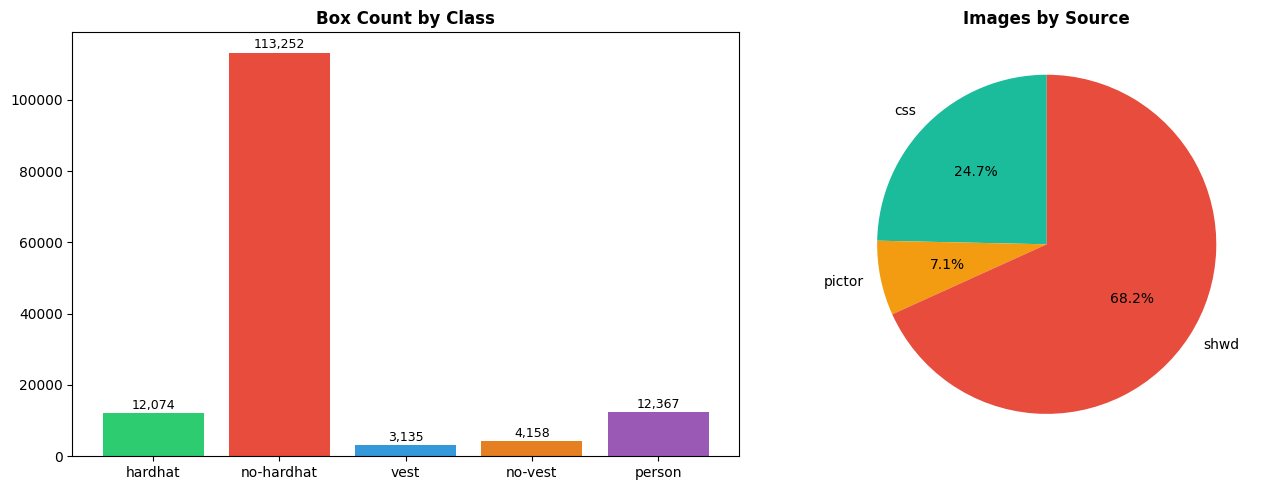

In [32]:
# 9.2 Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cn = [UNIFIED_CLASSES[i] for i in range(NUM_CLASSES)]
cc = [class_distribution.get(i,0) for i in range(NUM_CLASSES)]
axes[0].bar(cn, cc, color=["#2ecc71","#e74c3c","#3498db","#e67e22","#9b59b6"])
axes[0].set_title("Box Count by Class", fontweight="bold")
for i,c in enumerate(cc): axes[0].text(i,c+max(cc)*0.01,f"{c:,}",ha="center",fontsize=9)
sl=list(source_distribution.keys()); sv=list(source_distribution.values())
axes[1].pie(sv,labels=sl,autopct="%1.1f%%",colors=["#1abc9c","#f39c12","#e74c3c"][:len(sl)],startangle=90)
axes[1].set_title("Images by Source", fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT/"results"/"data_acquisition_summary.png",dpi=150,bbox_inches="tight")
plt.show()

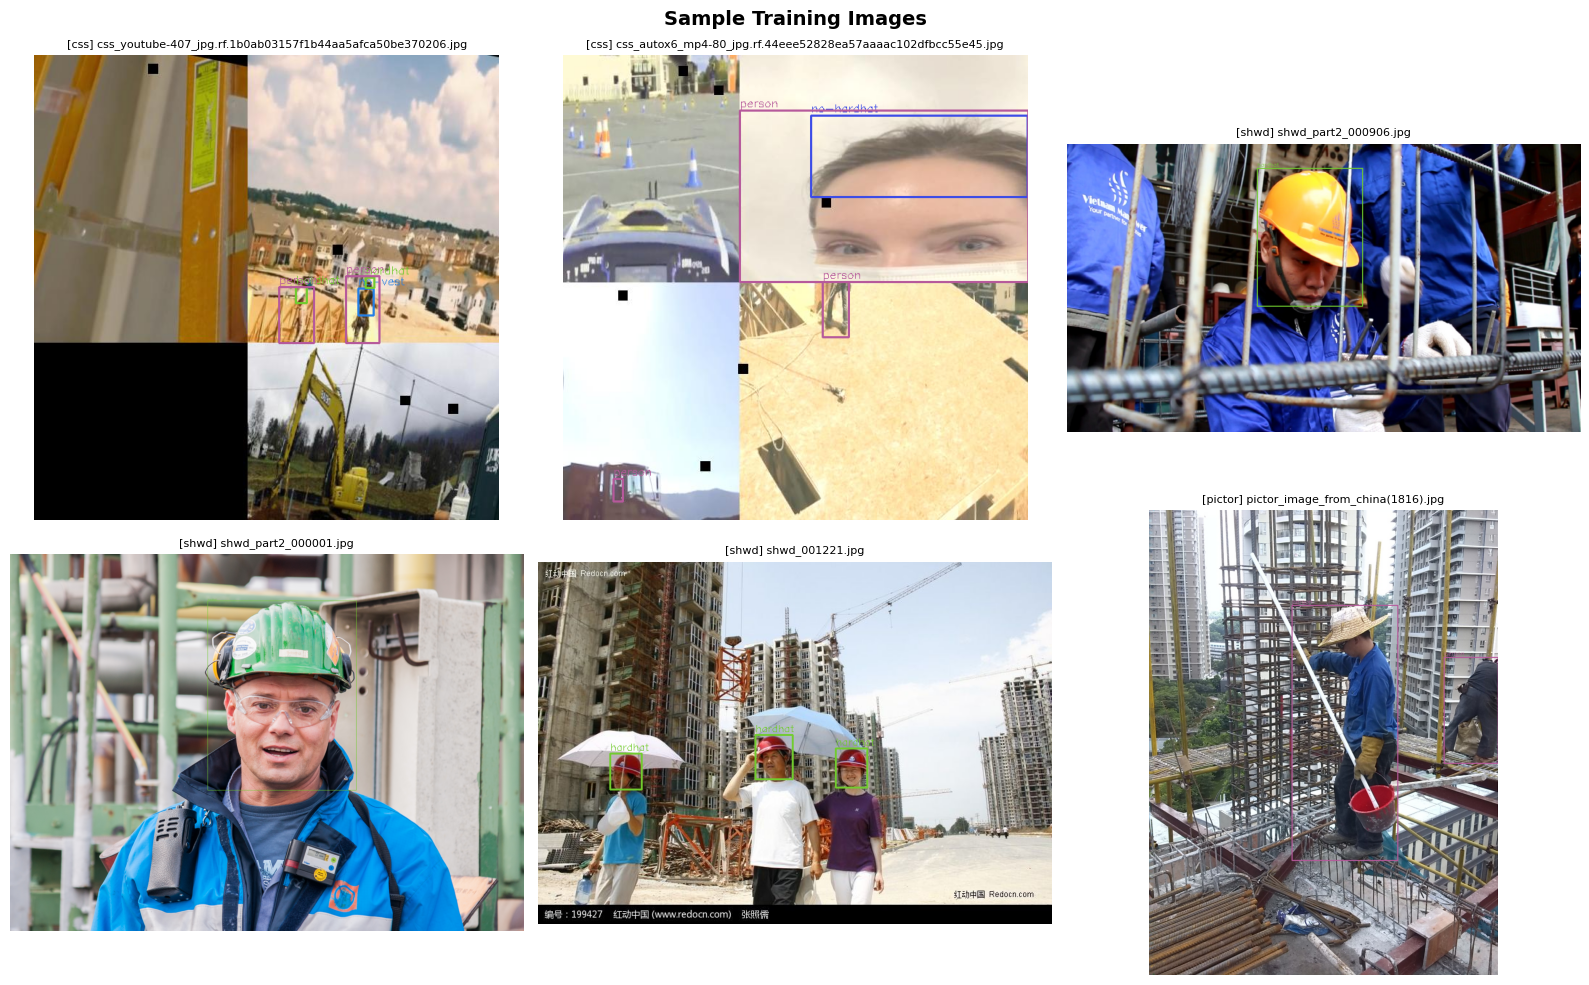

In [33]:
# 9.3 Sample images
import cv2
COLS={0:(46,204,113),1:(231,76,60),2:(52,152,219),3:(230,126,34),4:(155,89,182)}
def draw(ip,lp):
    img=cv2.imread(str(ip))
    if img is None: return np.zeros((200,200,3),dtype=np.uint8)
    h,w=img.shape[:2]
    with open(lp) as f:
        for line in f:
            p=line.strip().split()
            if len(p)!=5: continue
            cid=int(p[0]); xc,yc,bw,bh=[float(x) for x in p[1:]]
            x1,y1,x2,y2=int((xc-bw/2)*w),int((yc-bh/2)*h),int((xc+bw/2)*w),int((yc+bh/2)*h)
            col=COLS.get(cid,(255,255,255))
            cv2.rectangle(img,(x1,y1),(x2,y2),col,2)
            cv2.putText(img,UNIFIED_CLASSES.get(cid,"?"),(x1,y1-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,col,1)
    return cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

ti=sorted((MERGED_IMG_DIR/"train").glob("*"))
samp=random.sample(ti,min(6,len(ti)))
fig,axes=plt.subplots(2,3,figsize=(16,10))
for ax,ip in zip(axes.flat,samp):
    lp=MERGED_LBL_DIR/"train"/(ip.stem+".txt")
    ax.imshow(draw(ip,lp)); ax.set_title(f"[{ip.stem.split(chr(95))[0]}] {ip.name}",fontsize=8); ax.axis("off")
for ax in axes.flat[len(samp):]: ax.axis("off")
plt.suptitle("Sample Training Images",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT/"results"/"sample_training_images.png",dpi=150,bbox_inches="tight")
plt.show()

In [34]:
# Done
print("\n" + "=" * 65)
print("  NB01 DATA ACQUISITION - COMPLETE")
print("=" * 65)
print(f"  YAML:    {yaml_path.resolve()}")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Images:  {total_images:,}")
print(f"  Boxes:   {total_boxes:,}")
print(f"\n  -> Next: NB02_Forensic_Exploration.ipynb")


  NB01 DATA ACQUISITION - COMPLETE
  YAML:    C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\ppe_dataset.yaml
  Classes: 5
  Images:  10,864
  Boxes:   144,986

  -> Next: NB02_Forensic_Exploration.ipynb
